# Exercice 6 - Application of supervised learning

Dataset choisi: **Global Video Game Sales and Ratings** ("Video Games Sales as at 22 Dec 2016", 16 719 jeux).

Source: Kaggle, https://www.kaggle.com/datasets/thedevastator/global-video-game-sales-and-ratings

Le CSV est charge depuis `reponse/data/global_video_game_sales_and_ratings.csv`.

## Presentation du dataset

Le dataset rassemble des jeux video publies sur plusieurs plateformes. Chaque ligne represente un jeu ou une sortie de jeu, avec des informations commerciales et descriptives: plateforme, genre, editeur, annee de sortie, classification d'age, scores critiques, scores utilisateurs, nombre de notes et ventes.

Le probleme choisi est un probleme de classification binaire: predire si un jeu est un succes commercial. On construit la cible `success` a partir de `Global_Sales`: un jeu est considere comme un succes si ses ventes mondiales sont superieures a la mediane observee sur le train set.

Variables candidates: `Platform`, `Genre`, `Publisher`, `Year_of_Release`, `Critic_Score`, `Critic_Count`, `User_Score`, `User_Count`, `Rating`.

Variables exclues: `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, car elles sont des composantes directes de `Global_Sales`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

DATA_PATH_CANDIDATES = [
    Path('reponse/data/global_video_game_sales_and_ratings.csv'),
    Path('../data/global_video_game_sales_and_ratings.csv'),
    Path('../../reponse/data/global_video_game_sales_and_ratings.csv'),
]
DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), DATA_PATH_CANDIDATES[0])
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset absent: {DATA_PATH}. Telechargez le CSV Kaggle puis modifiez DATA_PATH si besoin."
    )

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Name                   str
Platform               str
Year_of_Release    float64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score         float64
User_Count         float64
Developer              str
Rating                 str
dtype: object

Valeurs manquantes par colonne:
User_Score         9129
User_Count         9129
Critic_Score       8582
Critic_Count       8582
Rating             6769
Developer          6623
Year_of_Release     269
Publisher            54
Name                  2
Genre                 2
NA_Sales              0
Platform              0
JP_Sales              0
EU_Sales              0
Other_Sales           0
Global_Sales          0
dtype: int64


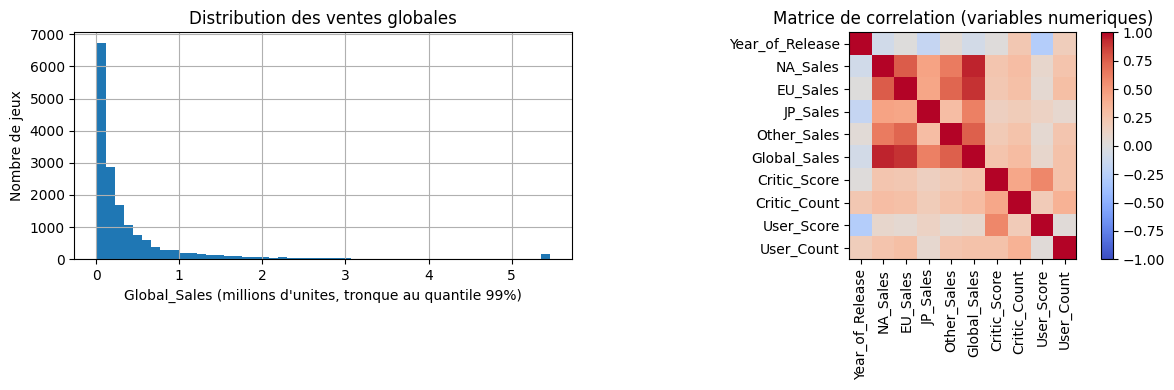

In [2]:
aliases = {
    'Year_of_Release': ['Year_of_Release', 'Year', 'year_of_release'],
    'Global_Sales': ['Global_Sales', 'Global Sales', 'global_sales'],
    'User_Score': ['User_Score', 'User Score', 'user_score'],
}
for canonical, names in aliases.items():
    for name in names:
        if name in df.columns and name != canonical:
            df = df.rename(columns={name: canonical})
            break

if 'User_Score' in df.columns:
    df['User_Score'] = pd.to_numeric(df['User_Score'].replace('tbd', np.nan), errors='coerce')

df = df.dropna(subset=['Global_Sales']).copy()

# Analyse generale: types, valeurs manquantes, distribution des ventes, correlations
print(df.dtypes)
print()
print('Valeurs manquantes par colonne:')
print(df.isna().sum().sort_values(ascending=False))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Global_Sales'].clip(upper=df['Global_Sales'].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_xlabel("Global_Sales (millions d'unites, tronque au quantile 99%)")
axes[0].set_ylabel('Nombre de jeux')
axes[0].set_title('Distribution des ventes globales')

numeric_cols = df.select_dtypes(include='number')
im = axes[1].imshow(numeric_cols.corr(), cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(numeric_cols.columns)))
axes[1].set_xticklabels(numeric_cols.columns, rotation=90)
axes[1].set_yticks(range(len(numeric_cols.columns)))
axes[1].set_yticklabels(numeric_cols.columns)
axes[1].set_title('Matrice de correlation (variables numeriques)')
fig.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

In [3]:
candidate_features = [
    'Platform', 'Genre', 'Publisher', 'Year_of_Release', 'Critic_Score',
    'Critic_Count', 'User_Score', 'User_Count', 'Rating'
]
features = [c for c in candidate_features if c in df.columns]

X = df[features]
y_sales = df['Global_Sales']
X_train, X_test, y_sales_train, y_sales_test = train_test_split(
    X, y_sales, test_size=0.2, random_state=42
)
threshold = y_sales_train.median()
y_train = (y_sales_train > threshold).astype(int)
y_test = (y_sales_test > threshold).astype(int)
print('Seuil de succes (mediane train):', threshold, "millions d'unites")
print('Proportion de succes train/test:', y_train.mean().round(3), y_test.mean().round(3))

numeric_features = [c for c in features if X_train[c].dtype.kind in 'ifc']
categorical_features = [c for c in features if c not in numeric_features]

preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10))]), categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LogisticRegression': (
        Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=3000))]),
        {'clf__C': [0.03, 0.1, 0.3, 1, 3]},
    ),
    'RandomForest': (
        Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
        {'clf__n_estimators': [200, 400], 'clf__max_depth': [None, 10, 20], 'clf__min_samples_leaf': [1, 3]},
    ),
    'GradientBoosting': (
        Pipeline([('prep', preprocess), ('clf', GradientBoostingClassifier(random_state=42))]),
        {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.03, 0.1], 'clf__max_depth': [2, 3]},
    ),
}

results = []
for name, (estimator, grid) in models.items():
    search = GridSearchCV(estimator, grid, cv=cv, scoring='f1', n_jobs=-1)
    search.fit(X_train, y_train)
    pred = search.predict(X_test)
    proba = search.predict_proba(X_test)[:, 1]
    results.append({
        'model': name,
        'cv_f1': search.best_score_,
        'test_accuracy': accuracy_score(y_test, pred),
        'test_f1': f1_score(y_test, pred),
        'test_auc': roc_auc_score(y_test, proba),
        'params': search.best_params_,
    })

for row in sorted(results, key=lambda r: r['test_f1'], reverse=True):
    print(row)

Seuil de succes (mediane train): 0.17 millions d'unites
Proportion de succes train/test: 0.489 0.498


{'model': 'GradientBoosting', 'cv_f1': np.float64(0.7405793796280341), 'test_accuracy': 0.7559808612440191, 'test_f1': 0.751219512195122, 'test_auc': 0.8394744090544872, 'params': {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}}
{'model': 'RandomForest', 'cv_f1': np.float64(0.7558816953371567), 'test_accuracy': 0.7508971291866029, 'test_f1': 0.750524109014675, 'test_auc': 0.8260355855082417, 'params': {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}}
{'model': 'LogisticRegression', 'cv_f1': np.float64(0.7334621285102332), 'test_accuracy': 0.7230861244019139, 'test_f1': 0.7265209686946249, 'test_auc': 0.8092372796474359, 'params': {'clf__C': 1}}


## Discussion des resultats

Resultats sur le test set (20% des 16 717 jeux avec ventes connues, jamais utilise pendant la selection de modele; la selection est faite par validation croisee 5-fold sur le train):

| Modele | CV F1 | Test accuracy | Test F1 | Test ROC-AUC |
|---|---:|---:|---:|---:|
| GradientBoosting | 0.741 | 0.756 | 0.751 | 0.839 |
| RandomForest | 0.756 | 0.751 | 0.751 | 0.826 |
| LogisticRegression | 0.733 | 0.723 | 0.727 | 0.809 |

- **Meilleur modele**: le GradientBoosting (accuracy test 0.756, ROC-AUC test 0.839). Le RandomForest est tres proche; la regression logistique, lineaire, reste en retrait, ce qui indique des effets non lineaires ou des interactions entre variables (par exemple entre plateforme et annee de sortie).
- **Le probleme est-il resolu?** Les classes sont equilibrees par construction (seuil = mediane des ventes train, 0.17 million d'unites), donc une prediction aleatoire donnerait 0.5 d'accuracy. Atteindre ~0.76 d'accuracy et ~0.84 d'AUC montre que les caracteristiques descriptives d'un jeu (plateforme, genre, editeur, annee, scores) portent une information reelle sur son succes commercial, sans le determiner completement — ce qui est attendu: le succes depend aussi du marketing, de la licence, de la qualite percue au lancement, non presents dans les donnees.
- **Donnees manquantes**: les scores critiques/utilisateurs manquent pour plus de la moitie des jeux (environ 9 000 sur 16 700); ils sont imputes par la mediane. Cette imputation grossiere limite probablement l'apport de ces variables.
- **Limite de causalite temporelle**: les scores critiques et utilisateurs peuvent n'etre disponibles qu'apres la sortie du jeu. Le probleme resolu ici est donc "estimer si un jeu deja observe par le marche est un succes", pas une prediction avant lancement. Pour un scenario avant lancement, il faudrait retirer `Critic_Score`, `Critic_Count`, `User_Score`, `User_Count` et accepter une perte de score.